# **Desafío: emisión por sector económico**

Una de las tareas encomendadas por el equipo de supervisión de la agencia ambiental fue encontrar la emisión promedio de cada gas por año. Pudimos realizar esta tarea utilizando el método ```groupby()``` y ```pivot_table()``` para generar una tabla que contiene las emisiones a lo largo de los años para cada uno de los gases.

El equipo de supervisión ahora quiere saber la emisión promedio de cada uno de los sectores económicos en la columna "Nivel 1 - Sector". Como desafío, crea una tabla dinámica y una visualización gráfica que contenga esta información, usando solo el método ```pivot_table``` para construir la tabla, sin usar el método ```groupby```.

Puedes buscar información sobre cómo hacer esto en la documentación de Pandas sobre el método pivot_table.


---

In [1]:
import pandas as pd

In [2]:
url = "1-SEEG10_GERAL-BR_UF_2022.10.27-FINAL-SITE.xlsx"

emision_gases = pd.read_excel(url , sheet_name = 'GEE Estados')

c:\Users\User\Documentos\alura-learning\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [3]:
emision_gases.head()

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Emissão / Remoção / Bunker,Gás,Estado,Atividade Econômica,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Processos Industriais,Indústria Química,Produção de ABS,NaN,NaN,NaN,Emissão,COVNM (t),SP,OUTRA_IND,...,897.600,897.600,897.600,897.600,897.600,897.600,897.600,897.600,897.600,897.600
1,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,N2O (t),SP,OUTRA_IND,...,130.000,130.000,130.000,130.000,130.000,130.000,130.000,130.000,130.000,130.000
2,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,CO (t),SP,OUTRA_IND,...,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576
3,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,NOx (t),SP,OUTRA_IND,...,431.430,431.430,431.430,431.430,431.430,431.430,431.430,431.430,431.430,431.430
4,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,CO2e (t) GWP-AR2,SP,OUTRA_IND,...,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000


In [4]:
años = list(emision_gases.loc[:,1970:2021])
columnas = list(emision_gases.loc[:,'Nível 1 - Setor':'Produto'])

In [5]:
emision_gases_por_año = pd.melt(emision_gases, id_vars=columnas, value_vars=años, value_name='Emision', var_name='Año')

In [15]:
promedio_anual_sector = pd.pivot_table(emision_gases_por_año, columns='Nível 1 - Setor', values='Emision', index= 'Año', aggfunc='mean')
promedio_anual_sector

Nível 1 - Setor,Agropecuária,Energia,Mudança de Uso da Terra e Floresta,Processos Industriais,Resíduos
Año,,,,,
1970,46246.897891,16144.173809,0.000000,106549.168676,11684.883558
1971,48036.199926,17885.238953,0.000000,111532.507753,12676.706849
1972,50202.891428,19293.468629,0.000000,125701.525455,13709.697850
1973,52065.314764,22056.314835,0.000000,137657.110402,14715.248028
1974,54319.383750,23846.090343,0.000000,149941.779638,15710.616150
1975,59391.923086,25025.762137,0.000000,168471.860169,16667.446706
1976,62248.257994,27196.813347,0.000000,193826.482068,17539.505222
1977,62839.220909,27651.064663,0.000000,231505.609283,18462.455148
1978,62523.059780,29819.997276,0.000000,255736.210711,19327.840165


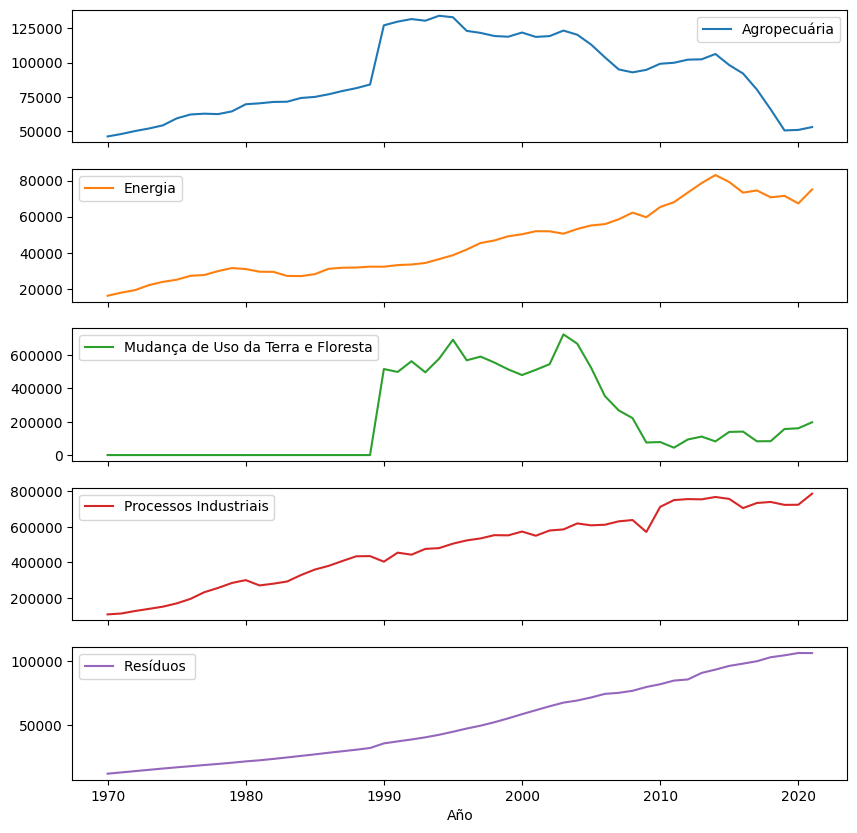

In [16]:
promedio_anual_sector.plot(subplots = True, figsize = (10,10));